In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from visualize import Island, Visualizer

In [2]:
islands_paths = [
    "results/11-04_16:26/BioT5",
    "results/11-04_16:50/BioT5",
    "results/11-04_17:14/BioT5",
    "results/11-04_17:43/BioT5",
    "results/11-04_18:27/BioT5",
    "results/11-04_18:50/BioT5",
    "results/11-04_19:47/BioT5",
    "results/11-04_20:12/BioT5",
    "results/11-04_20:41/BioT5",
    "results/11-04_21:11/BioT5"
]

islands = [Island(path) for path in islands_paths]
visualizer = Visualizer()

Loading results ...
Loading finished
Loading results ...
Loading finished
Loading results ...
Loading finished
Loading results ...
Loading finished
Loading results ...
Loading finished
Loading results ...
Loading finished
Loading results ...
Loading finished
Loading results ...
Loading finished
Loading results ...
Loading finished
Loading results ...
Loading finished


Similarity heatmap saved to visual_results/island_similarity_heatmap.png


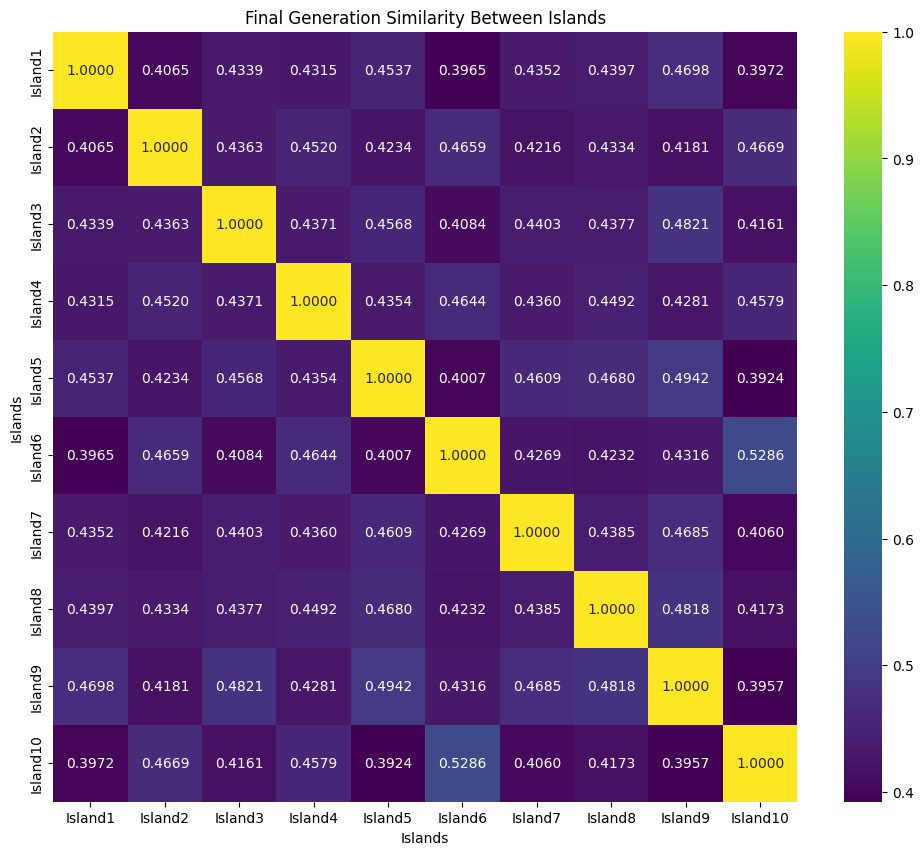

In [3]:
num_islands = len(islands)
similarity_matrix = pd.DataFrame(index=range(1, num_islands + 1), columns=range(1, num_islands + 1), dtype=float)

for i in range(num_islands):
    for j in range(i, num_islands):
        if i == j:
            similarity = 1.0
        else:
            similarity = visualizer.population_similarity(islands[i].populations[-1], islands[j].populations[-1])
        similarity_matrix.iloc[i, j] = similarity
        similarity_matrix.iloc[j, i] = similarity

plt.figure(figsize=(12, 10))
sns.heatmap(similarity_matrix, annot=True, fmt=".4f", cmap="viridis", xticklabels=[f"Island{k}" for k in range(1, num_islands + 1)], yticklabels=[f"Island{k}" for k in range(1, num_islands + 1)])
plt.title("Final Generation Similarity Between Islands")
plt.xlabel("Islands")
plt.ylabel("Islands")
output_path = "visual_results/island_similarity_heatmap.png"
plt.savefig(output_path)

print(f"Similarity heatmap saved to {output_path}")

In [6]:
num_islands = len(islands)
similarities = []

for i in range(num_islands):
    for j in range(i + 1, num_islands):
        similarity = visualizer.population_similarity(islands[i].populations[-1], islands[j].populations[-1])
        similarities.append(similarity)

mean_similarity = np.mean(similarities)
std_similarity = np.std(similarities)

print(f"Number of similarity pairs: {len(similarities)}")
print(f"Mean similarity: {mean_similarity:.4f}")
print(f"Standard deviation of similarity: {std_similarity:.4f}")

Number of similarity pairs: 45
Mean similarity: 0.4392
Standard deviation of similarity: 0.0283
